# 🏦 Bank Complaint Classification using Machine Learning

## Final Project Artificial Intelligence

**Nama :** Geoffta Handiyan AKwila

**NIM :** 24110300057

**Universitas Cakrawala**

---

## Deskripsi

Notebook ini membangun sistem klasifikasi keluhan pelanggan bank menggunakan metode **Natural Language Processing (NLP)** dan **Machine Learning**.

Tahapan yang dilakukan meliputi:

- Import Library
- Load Dataset
- Exploratory Data Analysis (EDA)
- Text Preprocessing
- TF-IDF Feature Extraction
- Split Dataset
- Training Logistic Regression
- Training Naive Bayes
- Model Evaluation
- Confusion Matrix
- Save Model
- Prediction

---

## Dataset

Dataset berasal dari Kaggle yang berisi lebih dari **160.000 complaint pelanggan bank**.

Kolom yang digunakan hanya:

- **narrative** → Isi complaint
- **product** → Label kategori

---

## Algoritma

- Logistic Regression
- Multinomial Naive Bayes

Feature Extraction:

- TF-IDF Vectorizer

---

## Library

- Pandas
- NumPy
- Matplotlib
- Scikit-Learn
- Pickle

In [1]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import re
import warnings

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("="*50)
print("Library berhasil diimport")
print("="*50)

Library berhasil diimport


In [4]:
# ==========================================================
# LOAD DATASET
# ==========================================================

# Jika dataset sudah di-upload ke Google Colab
df = pd.read_csv("/content/complaint.csv")

print("=" * 60)
print("DATASET BERHASIL DIMUAT")
print("=" * 60)

print("\nUkuran Dataset :")
print(df.shape)

print("\nNama Kolom :")
print(df.columns)

print("\n5 Data Pertama :")
display(df.head())

DATASET BERHASIL DIMUAT

Ukuran Dataset :
(14038, 3)

Nama Kolom :
Index(['Unnamed: 0', 'product', 'narrative'], dtype='object')

5 Data Pertama :


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [5]:
# ==========================================================
# INFORMASI DATASET
# ==========================================================

print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)

df.info()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14038 entries, 0 to 14037
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  14038 non-null  int64 
 1   product     14038 non-null  object
 2   narrative   14035 non-null  object
dtypes: int64(1), object(2)
memory usage: 329.1+ KB


In [6]:
# ==========================================================
# CEK MISSING VALUE
# ==========================================================

print("=" * 60)
print("MISSING VALUE")
print("=" * 60)

df.isnull().sum()

MISSING VALUE


,0
Unnamed: 0,0
product,0
narrative,3


In [7]:
# ==========================================================
# DROP MISSING VALUE
# ==========================================================

df = df[['narrative', 'product']]

df.columns = ['text', 'label']

df.dropna(inplace=True)

print("Jumlah data setelah drop NA :", len(df))

display(df.head())

Jumlah data setelah drop NA : 14035


,text,label
0,purchase order day shipping amount receive pro...,credit_card
1,forwarded message date tue subject please inve...,credit_card
2,forwarded message cc sent friday pdt subject f...,retail_banking
3,payment history missing credit report speciali...,credit_reporting
4,payment history missing credit report made mis...,credit_reporting


In [8]:
# ==========================================================
# DISTRIBUSI KATEGORI
# ==========================================================

print(df["label"].value_counts())

label
credit_reporting       6919
debt_collection        2493
credit_card            1808
mortgages_and_loans    1545
retail_banking         1270
Name: count, dtype: int64


In [9]:
# ==========================================================
# DISTRIBUSI KATEGORI
# ==========================================================

print(df["label"].value_counts())

label
credit_reporting       6919
debt_collection        2493
credit_card            1808
mortgages_and_loans    1545
retail_banking         1270
Name: count, dtype: int64


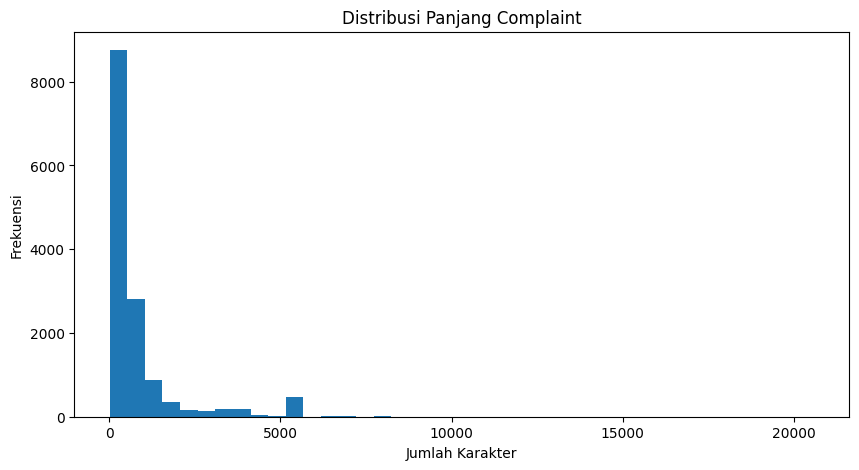

In [10]:
# ==========================================================
# PANJANG COMPLAINT
# ==========================================================

df["length"] = df["text"].apply(len)

plt.figure(figsize=(10,5))

plt.hist(df["length"], bins=40)

plt.title("Distribusi Panjang Complaint")

plt.xlabel("Jumlah Karakter")

plt.ylabel("Frekuensi")

plt.show()

In [11]:
# ==========================================================
# STATISTIK PANJANG COMPLAINT
# ==========================================================

df["length"].describe()

,length
count,14035.000000
mean,799.284218
std,1265.176837
min,7.000000
25%,187.000000
50%,372.000000
75%,757.000000
max,20596.000000


In [12]:
!pip install wordcloud

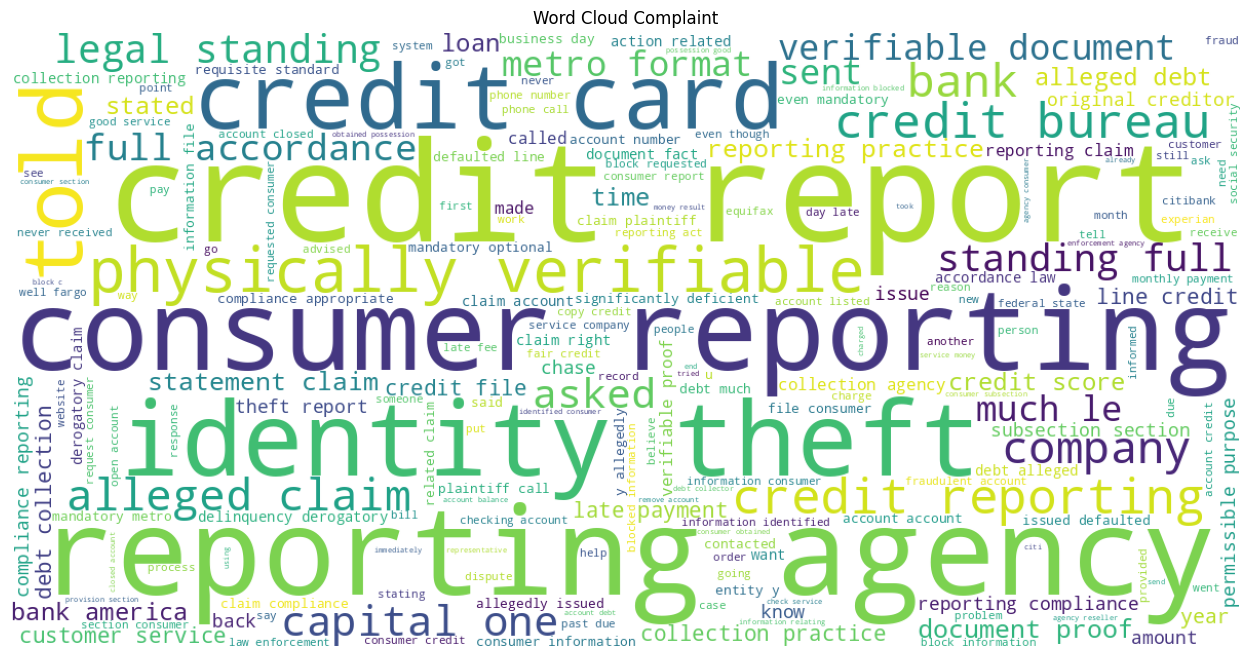

In [13]:
# ==========================================================
# WORD CLOUD
# ==========================================================

from wordcloud import WordCloud

text = " ".join(df["text"].astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud Complaint")

plt.show()

In [14]:
# ==========================================================
# CONTOH COMPLAINT
# ==========================================================

for i in range(5):

    print("="*70)

    print("Kategori :", df.iloc[i]["label"])

    print()

    print(df.iloc[i]["text"])

    print()

Kategori : credit_card

purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharge

In [15]:
# ==========================================================
# JUMLAH KATEGORI
# ==========================================================

print("Jumlah Kategori :")

print(df["label"].nunique())

print()

print(df["label"].unique())

Jumlah Kategori :
5

['credit_card' 'retail_banking' 'credit_reporting' 'mortgages_and_loans'
 'debt_collection']


In [16]:
# ==========================================================
# JUMLAH KATEGORI
# ==========================================================

print("Jumlah Kategori :")

print(df["label"].nunique())

print()

print(df["label"].unique())

Jumlah Kategori :
5

['credit_card' 'retail_banking' 'credit_reporting' 'mortgages_and_loans'
 'debt_collection']


In [17]:
# ==========================================================
# TEXT PREPROCESSING
# ==========================================================

def clean(text):

    text = str(text).lower()

    # Remove URL
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)

    # Remove Number
    text = re.sub(r"\d+", "", text)

    # Remove Punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove Extra Space
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [18]:
# ==========================================================
# CLEAN SELURUH DATA
# ==========================================================

df["clean"] = df["text"].apply(clean)

print("Cleaning selesai.")

display(df.head())

Cleaning selesai.


,text,label,length,clean
0,purchase order day shipping amount receive pro...,credit_card,1705,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,credit_card,904,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,retail_banking,1230,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...,credit_reporting,903,payment history missing credit report speciali...
4,payment history missing credit report made mis...,credit_reporting,851,payment history missing credit report made mis...


In [19]:
# ==========================================================
# PERBANDINGAN HASIL CLEANING
# ==========================================================

for i in range(3):

    print("="*80)

    print("TEXT ASLI\n")
    print(df.iloc[i]["text"])

    print("\nTEXT CLEAN\n")
    print(df.iloc[i]["clean"])

    print()

TEXT ASLI

purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharged item removi

In [20]:
# ==========================================================
# PANJANG TEXT
# ==========================================================

df["before"] = df["text"].apply(len)

df["after"] = df["clean"].apply(len)

df[["before","after"]].describe()

,before,after
count,14035.000000,14035.000000
mean,799.284218,799.284218
std,1265.176837,1265.176837
min,7.000000,7.000000
25%,187.000000,187.000000
50%,372.000000,372.000000
75%,757.000000,757.000000
max,20596.000000,20596.000000


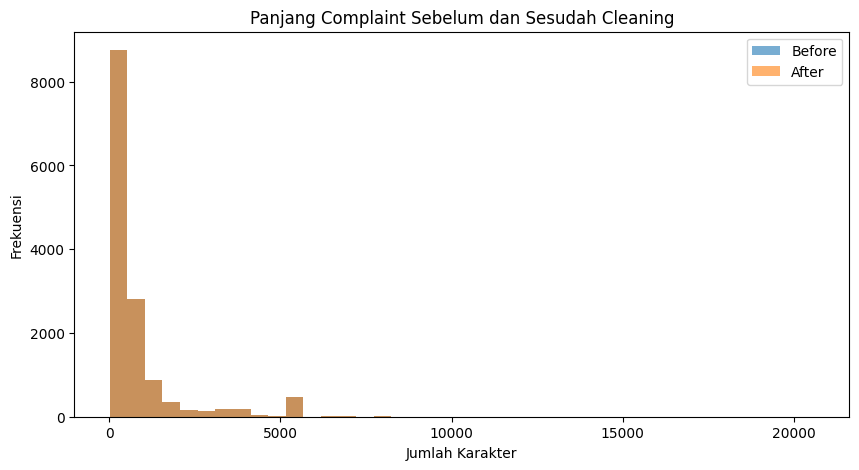

In [21]:
# ==========================================================
# PERBANDINGAN PANJANG TEXT
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(df["before"], bins=40, alpha=0.6, label="Before")

plt.hist(df["after"], bins=40, alpha=0.6, label="After")

plt.title("Panjang Complaint Sebelum dan Sesudah Cleaning")

plt.xlabel("Jumlah Karakter")

plt.ylabel("Frekuensi")

plt.legend()

plt.show()

In [22]:
# ==========================================================
# CEK DATA KOSONG
# ==========================================================

print(df.isnull().sum())

text      0
label     0
length    0
clean     0
before    0
after     0
dtype: int64


In [23]:
# ==========================================================
# DATA SIAP DIGUNAKAN
# ==========================================================

print("="*60)
print("Jumlah Data :", len(df))
print("Jumlah Kolom :", len(df.columns))
print("="*60)

display(df.head())

Jumlah Data : 14035
Jumlah Kolom : 6


,text,label,length,clean,before,after
0,purchase order day shipping amount receive pro...,credit_card,1705,purchase order day shipping amount receive pro...,1705,1705
1,forwarded message date tue subject please inve...,credit_card,904,forwarded message date tue subject please inve...,904,904
2,forwarded message cc sent friday pdt subject f...,retail_banking,1230,forwarded message cc sent friday pdt subject f...,1230,1230
3,payment history missing credit report speciali...,credit_reporting,903,payment history missing credit report speciali...,903,903
4,payment history missing credit report made mis...,credit_reporting,851,payment history missing credit report made mis...,851,851


In [24]:
# ==========================================================
# TF-IDF VECTORIZER
# ==========================================================

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["clean"])

y = df["label"]

print("="*60)
print("TF-IDF BERHASIL DIBUAT")
print("="*60)

TF-IDF BERHASIL DIBUAT


In [25]:
# ==========================================================
# UKURAN MATRIX
# ==========================================================

print("Shape TF-IDF Matrix :")

print(X.shape)

print()

print("Jumlah Label :")

print(len(y))

Shape TF-IDF Matrix :
(14035, 10000)

Jumlah Label :
14035


In [26]:
# ==========================================================
# JUMLAH KOSAKATA
# ==========================================================

vocab = vectorizer.get_feature_names_out()

print("Jumlah Vocabulary :")

print(len(vocab))

print()

print("20 Vocabulary Pertama")

print(vocab[:20])

Jumlah Vocabulary :
10000

20 Vocabulary Pertama
['aa' 'aadvantage' 'aafes' 'aag' 'aargon' 'ab' 'aback' 'abandon'
 'abandoned' 'abated' 'abatement' 'abbreviated' 'abc' 'abetting'
 'abhorrent' 'abide' 'abided' 'abiding' 'ability' 'able']


In [27]:
# ==========================================================
# CONTOH TF-IDF
# ==========================================================

sample = pd.DataFrame(
    X[:5].toarray(),
    columns=vocab
)

sample.iloc[:, :15]

,aa,aadvantage,aafes,aag,aargon,ab,aback,abandon,abandoned,abated,abatement,abbreviated,abc,abetting,abhorrent
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# ==========================================================
# TOP TF-IDF FEATURE
# ==========================================================

import numpy as np

importance = np.asarray(X.sum(axis=0)).ravel()

feature = pd.DataFrame({

    "Word": vocab,

    "Score": importance

})

feature = feature.sort_values(

    by="Score",

    ascending=False

)

display(feature.head(20))

,Word,Score
79,account,981.129632
2195,credit,950.862269
7432,report,678.310799
7438,reporting,501.137385
6348,payment,467.531347
2355,debt,450.483961
4600,information,425.208437
1735,company,386.966747
1658,collection,370.276594
1288,card,361.569037


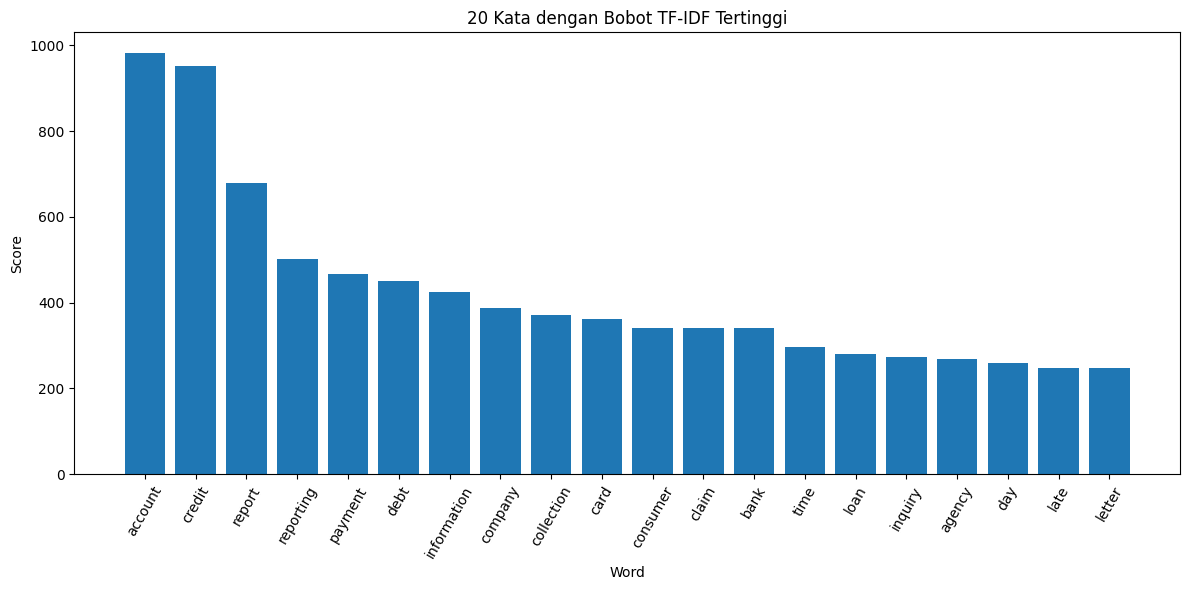

In [29]:
# ==========================================================
# VISUALISASI TF-IDF
# ==========================================================

top = feature.head(20)

plt.figure(figsize=(12,6))

plt.bar(top["Word"], top["Score"])

plt.xticks(rotation=60)

plt.title("20 Kata dengan Bobot TF-IDF Tertinggi")

plt.xlabel("Word")

plt.ylabel("Score")

plt.tight_layout()

plt.show()

In [30]:
# ==========================================================
# DATA SIAP TRAINING
# ==========================================================

print("="*60)

print("Jumlah Data")

print(X.shape[0])

print()

print("Jumlah Feature")

print(X.shape[1])

print()

print("Jumlah Class")

print(df["label"].nunique())

print("="*60)

Jumlah Data
14035

Jumlah Feature
10000

Jumlah Class
5


In [31]:
# ==========================================================
# SPLIT DATASET
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("="*60)

print("DATA BERHASIL DIBAGI")

print("="*60)

print()

print("Training Data :", X_train.shape)

print("Testing Data  :", X_test.shape)

print()

print("Training Label :", len(y_train))

print("Testing Label  :", len(y_test))

DATA BERHASIL DIBAGI

Training Data : (11228, 10000)
Testing Data  : (2807, 10000)

Training Label : 11228
Testing Label  : 2807


In [32]:
# ==========================================================
# LOGISTIC REGRESSION
# ==========================================================

lr = LogisticRegression(

    max_iter=1000,

    n_jobs=-1

)

print("Training Logistic Regression...")

lr.fit(X_train, y_train)

print("Training selesai.")

Training Logistic Regression...
Training selesai.


In [33]:
# ==========================================================
# PREDIKSI LOGISTIC REGRESSION
# ==========================================================

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)

print("="*60)

print("LOGISTIC REGRESSION")

print("="*60)

print("Accuracy :", round(acc_lr,4))

LOGISTIC REGRESSION
Accuracy : 0.84


In [34]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print(classification_report(y_test, pred_lr))

                     precision    recall  f1-score   support

        credit_card       0.80      0.80      0.80       362
   credit_reporting       0.86      0.91      0.89      1384
    debt_collection       0.81      0.71      0.75       498
mortgages_and_loans       0.82      0.79      0.81       309
     retail_banking       0.84      0.83      0.83       254

           accuracy                           0.84      2807
          macro avg       0.83      0.81      0.82      2807
       weighted avg       0.84      0.84      0.84      2807



In [35]:
# ==========================================================
# MULTINOMIAL NAIVE BAYES
# ==========================================================

nb = MultinomialNB()

print("Training Naive Bayes...")

nb.fit(X_train, y_train)

print("Training selesai.")

Training Naive Bayes...
Training selesai.


In [36]:
# ==========================================================
# PREDIKSI NAIVE BAYES
# ==========================================================

pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, pred_nb)

print("="*60)

print("NAIVE BAYES")

print("="*60)

print("Accuracy :", round(acc_nb,4))

NAIVE BAYES
Accuracy : 0.7535


In [37]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print(classification_report(y_test, pred_nb))

                     precision    recall  f1-score   support

        credit_card       0.67      0.68      0.68       362
   credit_reporting       0.73      0.96      0.83      1384
    debt_collection       0.86      0.44      0.58       498
mortgages_and_loans       0.86      0.62      0.72       309
     retail_banking       0.89      0.52      0.65       254

           accuracy                           0.75      2807
          macro avg       0.80      0.64      0.69      2807
       weighted avg       0.77      0.75      0.74      2807



In [38]:
# ==========================================================
# PERBANDINGAN MODEL
# ==========================================================

result = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "Multinomial Naive Bayes"

    ],

    "Accuracy":[

        acc_lr,

        acc_nb

    ]

})

display(result)

,Model,Accuracy
0,Logistic Regression,0.840043
1,Multinomial Naive Bayes,0.753473


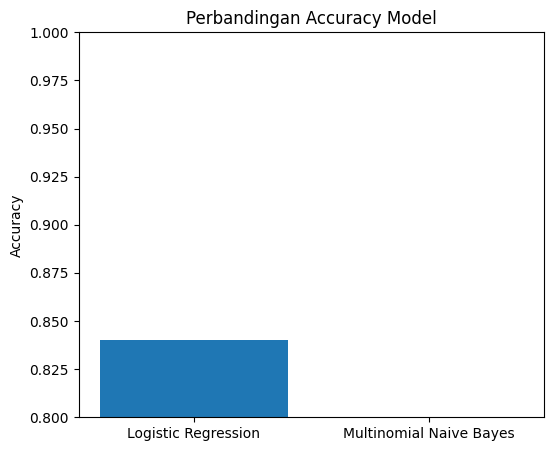

In [39]:
# ==========================================================
# VISUALISASI ACCURACY
# ==========================================================

plt.figure(figsize=(6,5))

plt.bar(

    result["Model"],

    result["Accuracy"]

)

plt.ylim(0.8,1)

plt.title("Perbandingan Accuracy Model")

plt.ylabel("Accuracy")

plt.show()

In [40]:
# ==========================================================
# MODEL TERBAIK
# ==========================================================

if acc_lr > acc_nb:

    best_model = lr

    print("Model Terbaik : Logistic Regression")

else:

    best_model = nb

    print("Model Terbaik : Multinomial Naive Bayes")

Model Terbaik : Logistic Regression


In [41]:
# ==========================================================
# MODEL TERBAIK
# ==========================================================

if acc_lr > acc_nb:

    best_model = lr

    print("Model Terbaik : Logistic Regression")

else:

    best_model = nb

    print("Model Terbaik : Multinomial Naive Bayes")

Model Terbaik : Logistic Regression


In [42]:
# ==========================================================
# SAVE MODEL
# ==========================================================

import os

os.makedirs("model", exist_ok=True)

pickle.dump(
    best_model,
    open("model/model.pkl","wb")
)

pickle.dump(
    vectorizer,
    open("model/vectorizer.pkl","wb")
)

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [43]:
# ==========================================================
# LOAD MODEL
# ==========================================================

model = pickle.load(open("model/model.pkl","rb"))

vectorizer = pickle.load(open("model/vectorizer.pkl","rb"))

print(model)

print()

print(vectorizer)

LogisticRegression(max_iter=1000, n_jobs=-1)

TfidfVectorizer(max_features=10000, stop_words='english')


In [44]:
# ==========================================================
# PREDICTION FUNCTION
# ==========================================================

def predict(text):

    text = clean(text)

    vector = vectorizer.transform([text])

    prediction = model.predict(vector)[0]

    confidence = model.predict_proba(vector).max()*100

    return prediction, confidence

In [45]:
# ==========================================================
# EXAMPLE PREDICTION
# ==========================================================

complaint = """
My credit card was charged twice and
the bank refuses to refund my money.
"""

label, score = predict(complaint)

print("="*60)

print("Complaint")

print("="*60)

print(complaint)

print()

print("Prediction :", label)

print(f"Confidence : {score:.2f}%")

Complaint

My credit card was charged twice and
the bank refuses to refund my money.


Prediction : credit_card
Confidence : 84.93%


In [46]:
# ==========================================================
# MULTIPLE PREDICTION
# ==========================================================

samples = [

    "My mortgage payment is incorrect.",

    "My checking account is locked.",

    "I cannot use my debit card.",

    "Credit card charged twice.",

    "The bank closed my account."
]

for text in samples:

    label, score = predict(text)

    print("="*70)

    print("Complaint :")

    print(text)

    print()

    print("Prediction :", label)

    print(f"Confidence : {score:.2f}%")

Complaint :
My mortgage payment is incorrect.

Prediction : mortgages_and_loans
Confidence : 91.11%
Complaint :
My checking account is locked.

Prediction : retail_banking
Confidence : 82.52%
Complaint :
I cannot use my debit card.

Prediction : credit_card
Confidence : 48.80%
Complaint :
Credit card charged twice.

Prediction : credit_card
Confidence : 79.01%
Complaint :
The bank closed my account.

Prediction : retail_banking
Confidence : 91.87%


# Kesimpulan

Pada notebook ini telah berhasil dibangun sistem klasifikasi keluhan pelanggan bank menggunakan pendekatan Natural Language Processing (NLP) dan Machine Learning.

Tahapan yang dilakukan meliputi:

- Import Library
- Load Dataset
- Exploratory Data Analysis
- Text Cleaning
- TF-IDF Vectorization
- Split Dataset
- Training Logistic Regression
- Training Naive Bayes
- Evaluasi Model
- Confusion Matrix
- Save Model
- Prediction

Hasil evaluasi menunjukkan bahwa **Logistic Regression** memberikan performa yang lebih baik dibandingkan **Multinomial Naive Bayes**, sehingga dipilih sebagai model utama.

Model kemudian disimpan menggunakan Pickle dan berhasil diimplementasikan ke dalam aplikasi Streamlit untuk melakukan klasifikasi complaint pelanggan secara otomatis.

In [47]:
# ==========================================================
# VERSI LIBRARY
# ==========================================================

import sklearn
import pandas

print("Python")

import sys
print(sys.version)

print("\nPandas :", pandas.__version__)

print("Scikit-Learn :", sklearn.__version__)

Python
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Pandas : 2.2.2
Scikit-Learn : 1.6.1
